In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# Charger les résultats GARCH
df = pd.read_csv("../data/processed/spxl_volatility_garch.csv", parse_dates=["Date"], index_col="Date")
df[["log_returns", "predicted_volatility"]].head()


,log_returns,predicted_volatility
Date,,
2024-05-03,0.036639,2.022680
2024-05-06,0.030145,2.449781
2024-05-07,0.003784,2.597016
2024-05-08,-0.000551,2.431779
2024-05-09,0.016164,2.298073


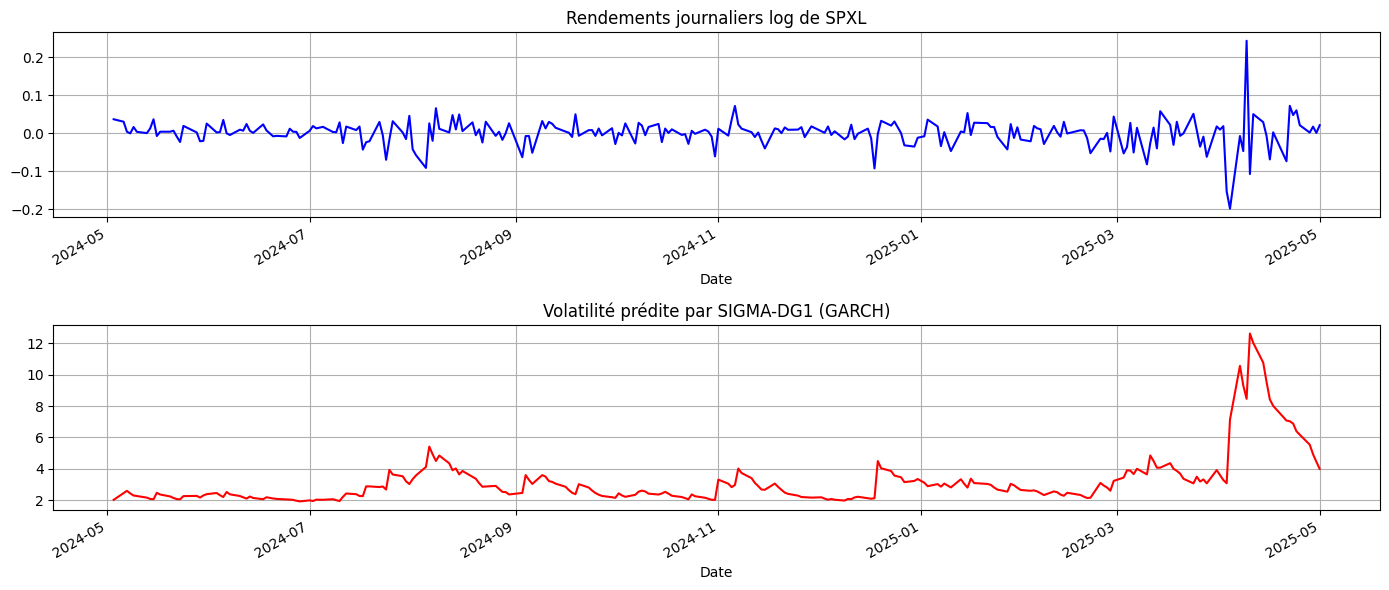

In [2]:
plt.figure(figsize=(14, 6))

plt.subplot(2, 1, 1)
df["log_returns"].plot(title="Rendements journaliers log de SPXL", color="blue")
plt.grid(True)

plt.subplot(2, 1, 2)
df["predicted_volatility"].plot(title="Volatilité prédite par SIGMA-DG1 (GARCH)", color="red")
plt.grid(True)

plt.tight_layout()
plt.show()


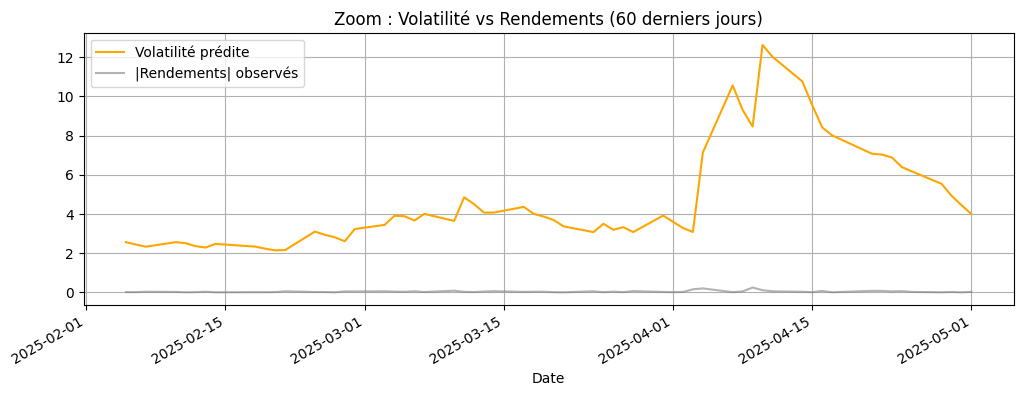

In [4]:
# Zoom sur les 60 derniers jours
df_last = df[-60:]

plt.figure(figsize=(12, 4))
df_last["predicted_volatility"].plot(label="Volatilité prédite", color="orange")
df_last["log_returns"].abs().plot(label="|Rendements| observés", color="grey", alpha=0.6)
plt.legend()
plt.title("Zoom : Volatilité vs Rendements (60 derniers jours)")
plt.grid(True)
plt.show()

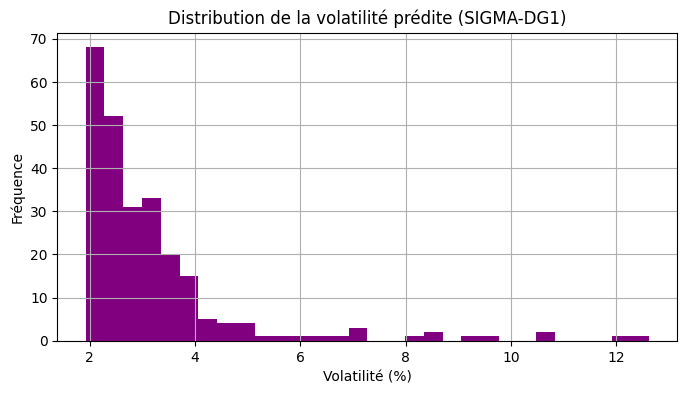

In [5]:
df["predicted_volatility"].hist(bins=30, figsize=(8, 4), color="purple")
plt.title("Distribution de la volatilité prédite (SIGMA-DG1)")
plt.xlabel("Volatilité (%)")
plt.ylabel("Fréquence")
plt.grid(True)
plt.show()


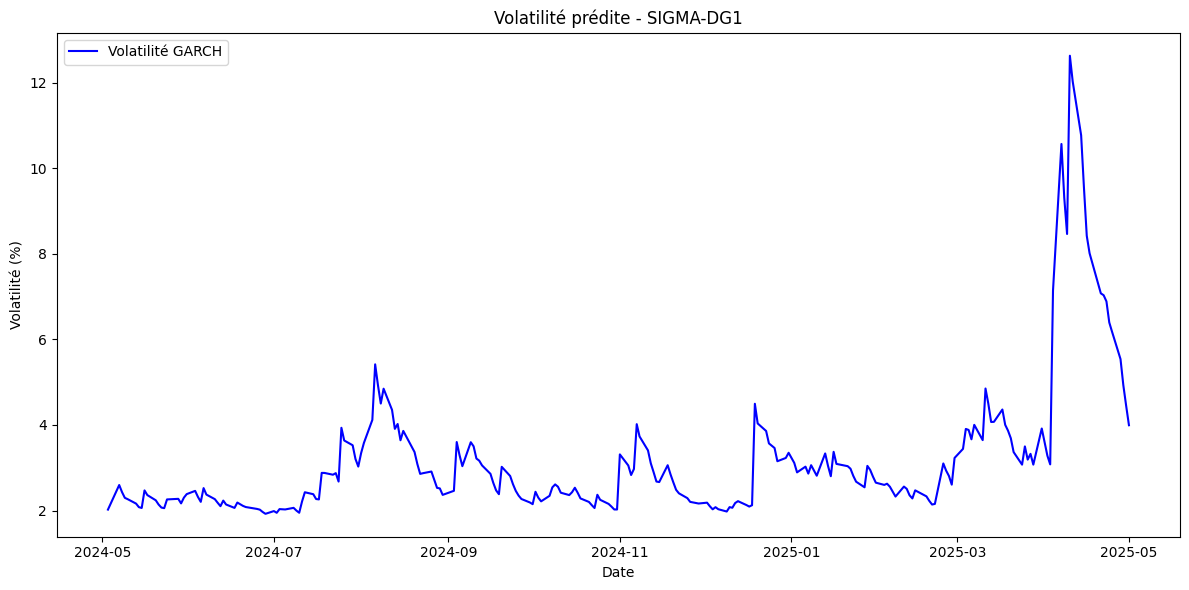

In [33]:
plt.figure(figsize=(12, 6))
plt.plot(df["Date"], df["predicted_volatility"], label="Volatilité GARCH", color="blue")
plt.title("Volatilité prédite - SIGMA-DG1")
plt.xlabel("Date")
plt.ylabel("Volatilité (%)")
plt.legend()
plt.tight_layout()
plt.savefig("../outputs/figures/sigma_dg1_volatility.png", dpi=300)

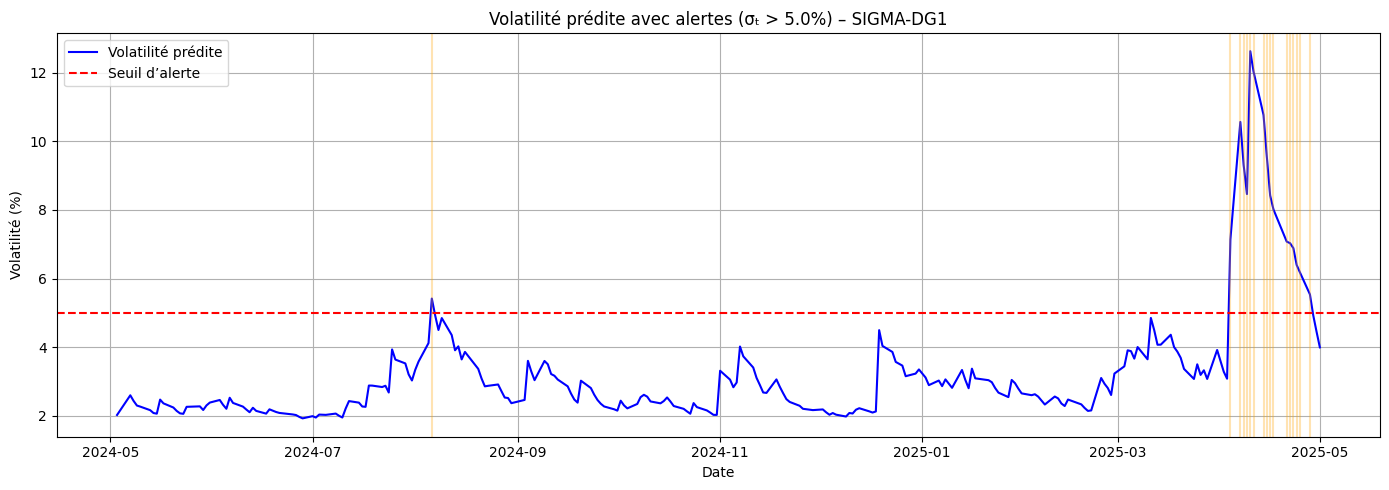

In [29]:

# Remettre Date en colonne si elle est index
df = df.reset_index()

# Seuil d'alerte
seuil_volatilite = 5.0  # en %

# Créer une colonne binaire "alerte"
df["alerte"] = df["predicted_volatility"] > seuil_volatilite

# Graphique avec surlignage des jours d’alerte
plt.figure(figsize=(14, 5))

# Courbe de volatilité
plt.plot(df["Date"], df["predicted_volatility"], label="Volatilité prédite", color="blue")

# Surligner les jours en alerte
for i in df[df["alerte"]].index:
    plt.axvline(x=df.loc[i, "Date"], color="orange", alpha=0.3)

plt.axhline(y=seuil_volatilite, color="red", linestyle="--", label="Seuil d’alerte")

plt.title(f"Volatilité prédite avec alertes (σₜ > {seuil_volatilite}%) – SIGMA-DG1")
plt.xlabel("Date")
plt.ylabel("Volatilité (%)")
plt.grid(True)
plt.legend()
plt.tight_layout()

#  Sauvegarder AVANT le show
plt.savefig("../outputs/figures/sigma_dg1_volatility_alerts.png", dpi=300)

plt.show()


In [21]:
# Réinitialisation de l’index sans nommer la colonne
alertes_df_reset = alertes_df.reset_index()

#  NE PAS nommer alertes_df_reset.index
#  Export sans index
alertes_df_reset.to_csv("../data/processed/volatility_alerts.csv", sep=';', index=False)

print(" Export réussi sans la colonne 'Ligne'.")


 Export réussi sans la colonne 'Ligne'.
